=== 完整Diffusion Model + 真实机械臂数据 ===
尝试加载: lerobot/pusht
✗ lerobot/pusht 加载失败: Feature type 'List' not found. Available feature types: ['Value', 'ClassLabel', 'Translation', 'TranslationVariableLanguages', 'LargeList', 'Sequence', 'Array2D', 'Array3D', 'Array4D', 'Array5D', 'Audio', 'Image', 'Video', 'Pdf']
尝试加载: lerobot/xarm_lift_medium
✓ 成功加载 11 个真实轨迹
模型参数: 2.37M
开始训练...


Training Flow Matching:   2%|▎                  | 15/800 [00:00<00:13, 56.47it/s]

Epoch 0, Loss: 1.647638


Training Flow Matching:  28%|████▋            | 220/800 [00:01<00:04, 140.26it/s]

Epoch 200, Loss: 0.650291


...

Epoch 600, Loss: 0.526928


Training Flow Matching: 100%|█████████████████| 800/800 [00:05<00:00, 136.36it/s]


使用CFG生成轨迹...
生成 guidance scale 1.0


生成 guidance scale 2.0


生成 guidance scale 5.0


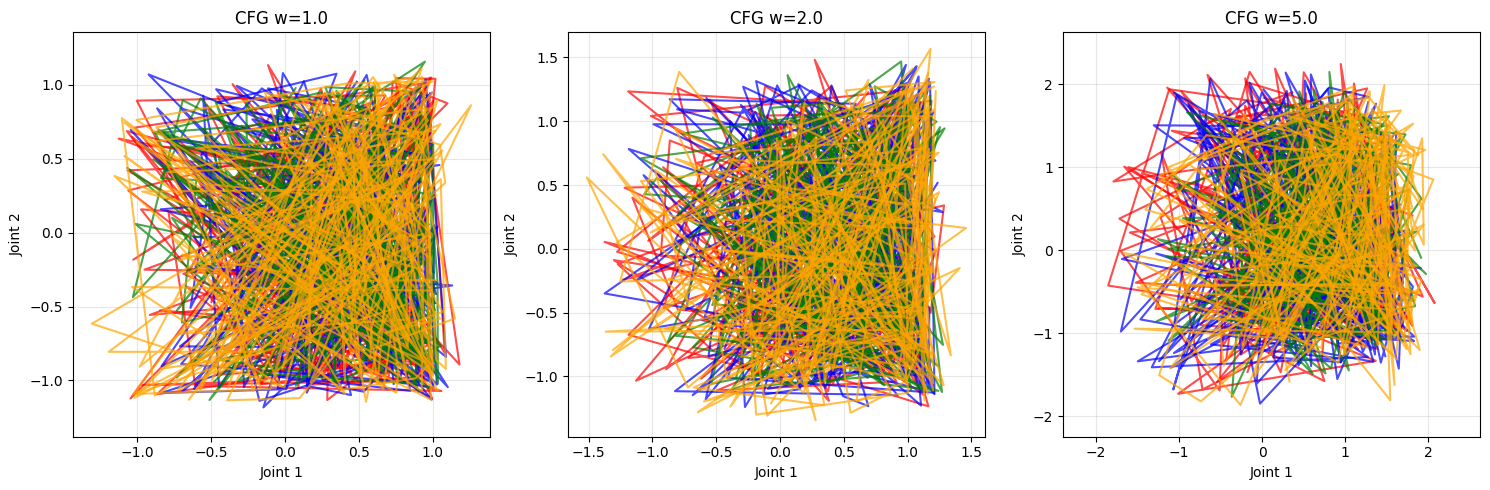

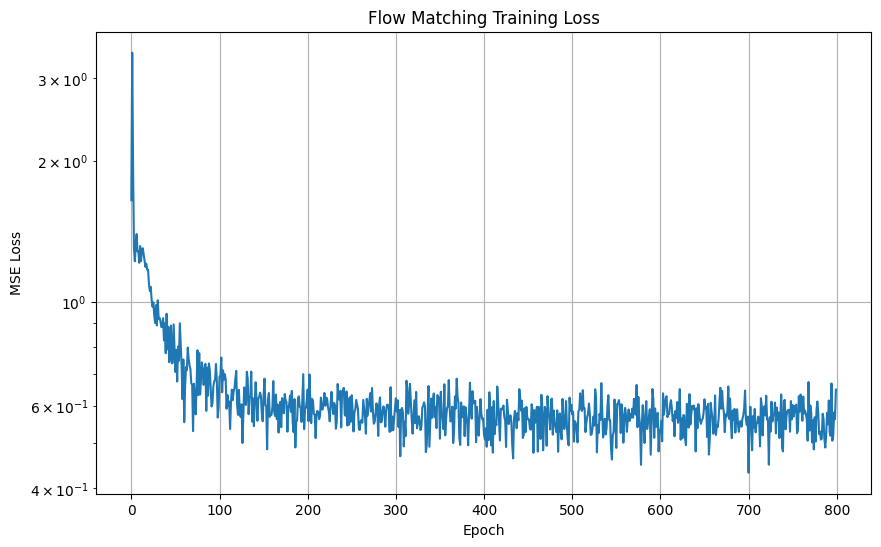

训练完成!
最终损失: 0.649783


In [1]:
from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple, Dict
import math
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.distributions as D
import torch.optim as optim
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 使用 HuggingFace datasets
from datasets import load_dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === 保留你原来的diffusion model架构 ===

class SequenceTransformer(nn.Module):
    def __init__(self, dim=2, seq_len=50, embed_dim=64, num_heads=4, num_labels=10, num_layers=3):
        super().__init__()
        self.dim = dim
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.num_labels = num_labels
        self.embed = nn.Linear(dim + 1 + num_labels, embed_dim)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(embed_dim, num_heads, batch_first=True), num_layers=num_layers
        )
        self.out = nn.Linear(embed_dim, dim)

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: Optional[torch.Tensor] = None) -> torch.Tensor:
        if x.dim() != 3 or x.shape[1] != self.seq_len or x.shape[2] != self.dim:
            raise ValueError(f"Expected x shape (bs, {self.seq_len}, {self.dim}), got {x.shape}")
        
        batch_size = x.shape[0]
        
        # Handle time embedding
        if t.dim() == 1:
            if t.shape[0] == 1:
                t = t.expand(batch_size)
            t = t.unsqueeze(-1)
        elif t.dim() == 2 and t.shape[1] > 1:
            t = t[:, 0:1]
        
        if t.shape[0] != batch_size:
            if t.shape[0] == 1:
                t = t.expand(batch_size, -1)
            else:
                raise ValueError(f"Time tensor batch size {t.shape[0]} doesn't match input batch size {batch_size}")
        
        t_emb = t.unsqueeze(1).expand(-1, self.seq_len, -1)
        
        # Handle y_emb
        if y is not None:
            if y.shape[0] != batch_size:
                raise ValueError(f"Label tensor batch size {y.shape[0]} doesn't match input batch size {batch_size}")
            y_emb = nn.functional.one_hot(y, num_classes=self.num_labels).unsqueeze(1).expand(-1, self.seq_len, -1).float()
        else:
            y_emb = torch.zeros(batch_size, self.seq_len, self.num_labels, device=x.device)
        
        x = torch.cat([x, t_emb, y_emb], dim=-1)
        x = self.embed(x)
        x = self.transformer(x)
        x = self.out(x)
        return x

class Sampleable(ABC):
    @abstractmethod
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        pass

class RealRobotTrajectoryDataset(Sampleable):
    """真实机械臂轨迹数据集 - 使用你的Sampleable接口"""
    
    def __init__(self, seq_len=50, dim=7, num_classes=4):
        self.seq_len = seq_len
        self.dim = dim
        self.num_classes = num_classes
        self.trajectories = []
        self.labels = []
        self._load_real_data()

    def _load_real_data(self):
        """尝试加载真实机械臂数据"""
        datasets_to_try = [
            "lerobot/pusht",
            "lerobot/xarm_lift_medium", 
            "lerobot/aloha_sim_insertion_human"
        ]
        
        for dataset_name in datasets_to_try:
            print(f"尝试加载: {dataset_name}")
            try:
                dataset = load_dataset(dataset_name, split="train", streaming=True)
                
                trajectories = []
                episode_actions = []
                
                for i, sample in enumerate(dataset.take(300)):  # 限制样本数
                    if 'action' in sample:
                        action = sample['action']
                        if isinstance(action, (list, tuple)):
                            action = np.array(action, dtype=np.float32)
                        elif hasattr(action, 'numpy'):
                            action = action.numpy().astype(np.float32)
                        else:
                            continue
                        
                        # 调整维度到指定大小
                        if len(action.shape) == 0:
                            action = np.array([action])
                        if action.shape[0] > self.dim:
                            action = action[:self.dim]
                        elif action.shape[0] < self.dim:
                            action = np.pad(action, (0, self.dim - action.shape[0]))
                        
                        episode_actions.append(action)
                        
                        # 每50帧作为一个轨迹
                        if len(episode_actions) >= self.seq_len:
                            trajectories.append(np.array(episode_actions[:self.seq_len]))
                            episode_actions = episode_actions[25:]  # 重叠采样
                
                if len(trajectories) > 10:
                    self.trajectories = trajectories[:50]  # 限制数量
                    # 根据轨迹模式分配类别
                    self.labels = [i % self.num_classes for i in range(len(self.trajectories))]
                    print(f"✓ 成功加载 {len(self.trajectories)} 个真实轨迹")
                    return
                
            except Exception as e:
                print(f"✗ {dataset_name} 加载失败: {e}")
                continue
        
        # 如果都失败了，生成模拟数据
        print("使用模拟机械臂数据")
        self._generate_simulated_data()

    def _generate_simulated_data(self):
        """生成模拟数据（使用你原来的逻辑）"""
        trajectories = []
        labels = []
        
        for i in range(50):
            t = np.linspace(0, 1, self.seq_len)
            label = i % self.num_classes
            
            if label == 0:  # 平滑插值
                start_pos = np.random.uniform(-1, 1, self.dim)
                end_pos = np.random.uniform(-1, 1, self.dim)
                traj = np.outer(1-t, start_pos) + np.outer(t, end_pos)
                
            elif label == 1:  # 正弦运动
                base_pos = np.random.uniform(-0.5, 0.5, self.dim)
                amplitude = np.random.uniform(0.1, 0.5, self.dim)
                frequency = np.random.uniform(0.5, 2.0)
                traj = base_pos + amplitude * np.sin(2 * np.pi * frequency * t.reshape(-1, 1))
                
            elif label == 2:  # 圆形运动
                center = np.random.uniform(-0.3, 0.3, self.dim)
                radius = np.random.uniform(0.2, 0.6)
                traj = np.tile(center, (self.seq_len, 1))
                traj[:, 0] += radius * np.cos(2 * np.pi * t)
                traj[:, 1] += radius * np.sin(2 * np.pi * t)
                
            else:  # 随机游走
                start_pos = np.random.uniform(-0.5, 0.5, self.dim)
                noise = np.random.normal(0, 0.05, (self.seq_len, self.dim))
                traj = np.cumsum(noise, axis=0) + start_pos
                traj = np.clip(traj, -2, 2)
            
            trajectories.append(traj.astype(np.float32))
            labels.append(label)
        
        self.trajectories = trajectories
        self.labels = labels

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """实现Sampleable接口"""
        indices = np.random.choice(len(self.trajectories), num_samples, replace=True)
        sampled_trajs = [self.trajectories[i] for i in indices]
        sampled_labels = [self.labels[i] for i in indices]
        
        trajectories = torch.tensor(np.array(sampled_trajs), dtype=torch.float32).to(device)
        labels = torch.tensor(sampled_labels, dtype=torch.long).to(device)
        
        return trajectories, labels

class IsotropicGaussian(Sampleable):
    def __init__(self, shape: List[int], std: float = 1.0):
        self.shape = shape
        self.std = std

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, None]:
        return torch.randn(num_samples, *self.shape).to(device) * self.std, None

# === 保留你的Flow Matching组件 ===

class ConditionalProbabilityPath(ABC):
    def __init__(self, p_simple: Sampleable, p_data: Sampleable):
        self.p_simple = p_simple
        self.p_data = p_data

    @abstractmethod
    def alpha_t(self, t: torch.Tensor) -> torch.Tensor:
        pass

    @abstractmethod
    def beta_t(self, t: torch.Tensor) -> torch.Tensor:
        pass

class GaussianConditionalProbabilityPath(ConditionalProbabilityPath):
    def __init__(self, p_data: Sampleable, p_simple: Sampleable, alpha, beta):
        super().__init__(p_simple, p_data)
        self.alpha = alpha
        self.beta = beta

    def alpha_t(self, t: torch.Tensor) -> torch.Tensor:
        return self.alpha(t)

    def beta_t(self, t: torch.Tensor) -> torch.Tensor:
        return self.beta(t)

class LinearAlpha:
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        return 1 - t

class LinearBeta:
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        return t

class CFGVectorFieldODE:
    def __init__(self, model, guidance_scale=1.0):
        self.model = model
        self.guidance_scale = guidance_scale
        self.drift_coefficient = self._compute_drift

    def _compute_drift(self, x, t, y=None):
        if y is not None and self.guidance_scale != 1.0:
            conditional = self.model(x, t, y)
            unconditional = self.model(x, t, None)
            return unconditional + self.guidance_scale * (conditional - unconditional)
        else:
            return self.model(x, t, y)

class EulerSimulator:
    def __init__(self, ode):
        self.ode = ode
        
    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        if h.dim() == 2 and h.shape[1] == 1:
            h = h.unsqueeze(-1)
        return xt + self.ode.drift_coefficient(xt, t, **kwargs) * h

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor, **kwargs):
        nts = ts.shape[1]
        for t_idx in tqdm(range(nts - 1), desc="Simulating", leave=False):
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
        return x

def train_flow_matching_model(model, p_data, p_simple, num_epochs=800, batch_size=32, lr=1e-3):
    """训练Flow Matching模型（使用你的原始架构）"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    
    losses = []
    
    for epoch in tqdm(range(num_epochs), desc="Training Flow Matching"):
        # 使用你的Sampleable接口
        x1, y = p_data.sample(batch_size)  # 真实轨迹
        x0, _ = p_simple.sample(batch_size)  # 噪声
        
        # 随机时间
        t = torch.rand(batch_size, 1).to(device)
        
        # Flow Matching路径
        alpha_t = (1 - t).unsqueeze(1)
        beta_t = t.unsqueeze(1)
        x_t = alpha_t * x0 + beta_t * x1
        
        # 真实速度场
        v_true = x1 - x0
        
        # 模型预测
        v_pred = model(x_t, t.squeeze(-1), y)
        
        # Flow matching损失
        loss = nn.MSELoss()(v_pred, v_true)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        if epoch % 200 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
    
    model.eval()
    return losses

def main():
    """主函数 - 整合你的完整diffusion model"""
    print("=== 完整Diffusion Model + 真实机械臂数据 ===")
    
    # 1. 初始化数据集（尝试真实数据）
    seq_len = 50
    dim = 7  # 7-DOF机械臂
    num_classes = 4
    
    p_data = RealRobotTrajectoryDataset(seq_len=seq_len, dim=dim, num_classes=num_classes)
    p_simple = IsotropicGaussian(shape=[seq_len, dim], std=1.0)
    
    # 2. 初始化你的SequenceTransformer
    unet = SequenceTransformer(
        dim=dim, 
        seq_len=seq_len, 
        embed_dim=128, 
        num_heads=8, 
        num_labels=num_classes,
        num_layers=4
    ).to(device)
    
    print(f"模型参数: {sum(p.numel() for p in unet.parameters())/1e6:.2f}M")
    
    # 3. 训练Flow Matching模型
    print("开始训练...")
    losses = train_flow_matching_model(
        unet, p_data, p_simple, 
        num_epochs=800, batch_size=16, lr=1e-3
    )
    
    # 4. 使用CFG生成轨迹
    print("使用CFG生成轨迹...")
    samples_per_class = 5
    guidance_scales = [1.0, 2.0, 5.0]
    
    fig, axes = plt.subplots(1, len(guidance_scales), figsize=(15, 5))
    if len(guidance_scales) == 1:
        axes = [axes]

    for idx, w in enumerate(guidance_scales):
        print(f"生成 guidance scale {w}")
        
        # 设置CFG
        ode = CFGVectorFieldODE(unet, guidance_scale=w)
        simulator = EulerSimulator(ode)

        # 采样条件
        y = torch.tensor([0, 1, 2, 3], dtype=torch.int64).repeat_interleave(samples_per_class).to(device)
        num_samples = y.shape[0]
        x0, _ = p_simple.sample(num_samples)

        # 生成过程
        ts = torch.linspace(0, 1, 50).view(1, -1, 1).expand(num_samples, -1, 1).to(device)
        
        with torch.no_grad():
            x1 = simulator.simulate(x0, ts, y=y)

        # 可视化（显示前2个维度）
        axes[idx].clear()
        x1_cpu = x1.cpu().numpy()
        
        colors = ['red', 'blue', 'green', 'orange']
        for i, traj in enumerate(x1_cpu):
            class_idx = y[i].cpu().item()
            # 显示轨迹在前2个关节的运动
            axes[idx].plot(traj[:, 0], traj[:, 1], 
                          alpha=0.7, color=colors[class_idx], linewidth=1.5)
        
        axes[idx].set_title(f"CFG w={w:.1f}")
        axes[idx].axis("equal")
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_xlabel("Joint 1")
        axes[idx].set_ylabel("Joint 2")

    plt.tight_layout()
    plt.show()
    
    # 显示训练损失
    plt.figure(figsize=(10, 6))
    plt.plot(losses)
    plt.title("Flow Matching Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.yscale('log')
    plt.grid(True)
    plt.show()
    
    print("训练完成!")
    print(f"最终损失: {losses[-1]:.6f}")
    
    return unet, p_data, x1

if __name__ == "__main__":
    model, dataset, generated_trajectories = main()